# Notebook 02 — CIR Model Calibration

---

## Purpose

This notebook calibrates the Cox-Ingersoll-Ross (CIR) short-rate model on historical 3-Month Treasury yield data.

**Why short-rate modelling matters:**  
Interest rates are the discounting backbone of all fixed-income instruments. A well-calibrated short-rate model lets us simulate future rate paths, derive bond prices analytically, and reconstruct an entire yield curve from a single observable input.

**CIR dynamics:**

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Meaning |
|-----------|---------|
| $\kappa$ | Speed of mean reversion |
| $\theta$ | Long-run mean of the short rate |
| $\sigma$ | Volatility coefficient |

**Objective:**  
Estimate $(\kappa, \theta, \sigma)$ from `cleaned_train.csv`, validate the calibration, and export the parameters to `results/cir_parameters.csv` for Notebook 03.


## 1. Imports and Configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy.optimize import minimize, OptimizeResult
from scipy.stats import jarque_bera, probplot
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROC_DIR    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR     = RESULTS_DIR / "figures"
PARAM_FILE = RESULTS_DIR / "cir_parameters.csv"

for d in [RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports successful.")
print(f"Results will be written to: {RESULTS_DIR}")

All imports successful.
Results will be written to: /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results


## 2. Load Cleaned Data

Load `cleaned_train.csv` and extract the **3M yield** as the short-rate proxy $r_t$.


In [4]:
def load_short_rate(
    path: Path,
    tenor: str = "3M"
) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Load cleaned Treasury yield data and extract the chosen short-rate proxy.

    Parameters

    path : Path
        Path to cleaned dataset.
    tenor : str
        Treasury maturity used as short rate.

    """

    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if tenor not in df.columns:
        raise KeyError(f"Column '{tenor}' not found. Available: {list(df.columns)}")

    r = df[tenor].dropna()
    return r, df


short_rate, df_train = load_short_rate(PROC_DIR / "cleaned_train.csv", tenor="3M")

print(f"Training observations : {len(short_rate)}")
print(f"Date range            : {short_rate.index[0].date()} -> {short_rate.index[-1].date()}")
print()
print("Summary statistics (3M yield):")
print(short_rate.describe().round(4).to_string())
print(f"\nNegative observations : {(short_rate < 0).sum()}")


Training observations : 1976
Date range            : 2016-05-19 -> 2024-04-26

Summary statistics (3M yield):
count    1976.0000
mean        0.0167
std         0.0166
min         0.0005
25%         0.0046
50%         0.0119
75%         0.0171
max         0.0520

Negative observations : 0


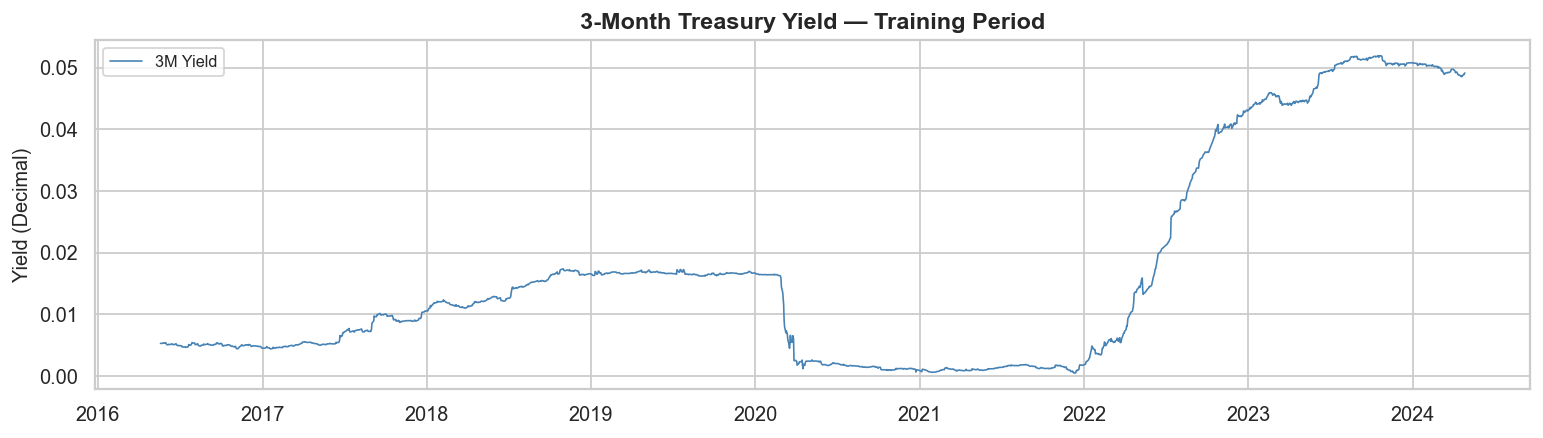

In [5]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(short_rate.index, short_rate.values, lw=0.9, color="steelblue", label="3M Yield")
ax.set_title("3-Month Treasury Yield — Training Period")
ax.set_ylabel("Yield (Decimal)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "short_rate_series.png", dpi=130, bbox_inches="tight")
plt.show()


## 3. Short-Rate Diagnostics for Calibration Method Selection

Before choosing an estimator, we evaluate four properties that directly determine which calibration framework is most appropriate.

| Diagnostic | Why it matters |
|-----------|----------------|
| Sampling frequency | Determines $\Delta t$; affects discretisation error |
| Distributional shape | Informs whether Gaussian-innovation assumptions hold |
| Autocorrelation | High persistence → large $1/\kappa$; convergence sensitivity |
| Frequency of non-positive values | CIR requires $r_t > 0$; negatives are a structural mismatch |


In [6]:
from scipy.stats import skew, kurtosis as kurt

# ── 3.1  Sampling frequency ───────────────────────────────────────────────
gaps    = short_rate.index.to_series().diff().dt.days.dropna()
dt_med  = gaps.median() / 365.0

print("── Sampling Frequency ──────────────────────────────────────────")
print(f"  Median gap (calendar days) : {gaps.median():.0f}")
print(f"  Delta-t in years           : {dt_med:.6f}")
print(f"  Approx frequency           : {'Daily' if gaps.median() <= 1 else 'Weekly' if gaps.median() <= 7 else 'Monthly'}")

# ── 3.2  Distribution ─────────────────────────────────────────────────────
r_vals     = short_rate.values
jb_s, jb_p = jarque_bera(r_vals)

print("\n── Distribution ────────────────────────────────────────────────")
print(f"  Mean      : {np.mean(r_vals):.4f}")
print(f"  Std       : {np.std(r_vals):.4f}")
print(f"  Skewness  : {skew(r_vals):.4f}")
print(f"  Ex. Kurt  : {kurt(r_vals):.4f}")
print(f"  JB stat   : {jb_s:.2f}  (p = {jb_p:.4f})")

# ── 3.3  Autocorrelation ──────────────────────────────────────────────────
acf_vals = acf(r_vals, nlags=5, fft=True)
lag1_corr = pd.Series(r_vals).autocorr(lag=1)

print("\n── Autocorrelation ─────────────────────────────────────────────")
print(f"  Lag-1 persistence : {lag1_corr:.4f}")
for lag, val in enumerate(acf_vals[1:], 1):
    print(f"  ACF lag {lag} : {val:.4f}")

# ── 3.4  Positivity ───────────────────────────────────────────────────────
n_neg  = (short_rate < 0).sum()
pct_neg = n_neg / len(short_rate) * 100
print("\n── Positivity ──────────────────────────────────────────────────")
print(f"  Obs with r_t < 0 : {n_neg} ({pct_neg:.2f} %)")
if n_neg > 0:
    print(f"  Min yield        : {short_rate.min():.4f}")
    print("  Warning: negative yields present — CIR strict positivity violated in-sample.")
else:
    print("  All observations positive — CIR assumption holds in-sample.")

near_zero = (short_rate < 0.0025).sum()
print(f"  Obs with r_t < 0.25% : {near_zero}")

print("\n── Method Selection Signals ───────────────────────────────────")
print("- Large sample size available")
print("- High-frequency observations")
print("- Strong persistence in short rates")
print("- No negative rates observed")
print("- Near-zero rate episodes present")


── Sampling Frequency ──────────────────────────────────────────
  Median gap (calendar days) : 1
  Delta-t in years           : 0.002740
  Approx frequency           : Daily

── Distribution ────────────────────────────────────────────────
  Mean      : 0.0167
  Std       : 0.0166
  Skewness  : 1.0642
  Ex. Kurt  : -0.2905
  JB stat   : 379.92  (p = 0.0000)

── Autocorrelation ─────────────────────────────────────────────
  Lag-1 persistence : 0.9999
  ACF lag 1 : 0.9988
  ACF lag 2 : 0.9976
  ACF lag 3 : 0.9964
  ACF lag 4 : 0.9951
  ACF lag 5 : 0.9938

── Positivity ──────────────────────────────────────────────────
  Obs with r_t < 0 : 0 (0.00 %)
  All observations positive — CIR assumption holds in-sample.
  Obs with r_t < 0.25% : 435

── Method Selection Signals ───────────────────────────────────
- Large sample size available
- High-frequency observations
- Strong persistence in short rates
- No negative rates observed
- Near-zero rate episodes present


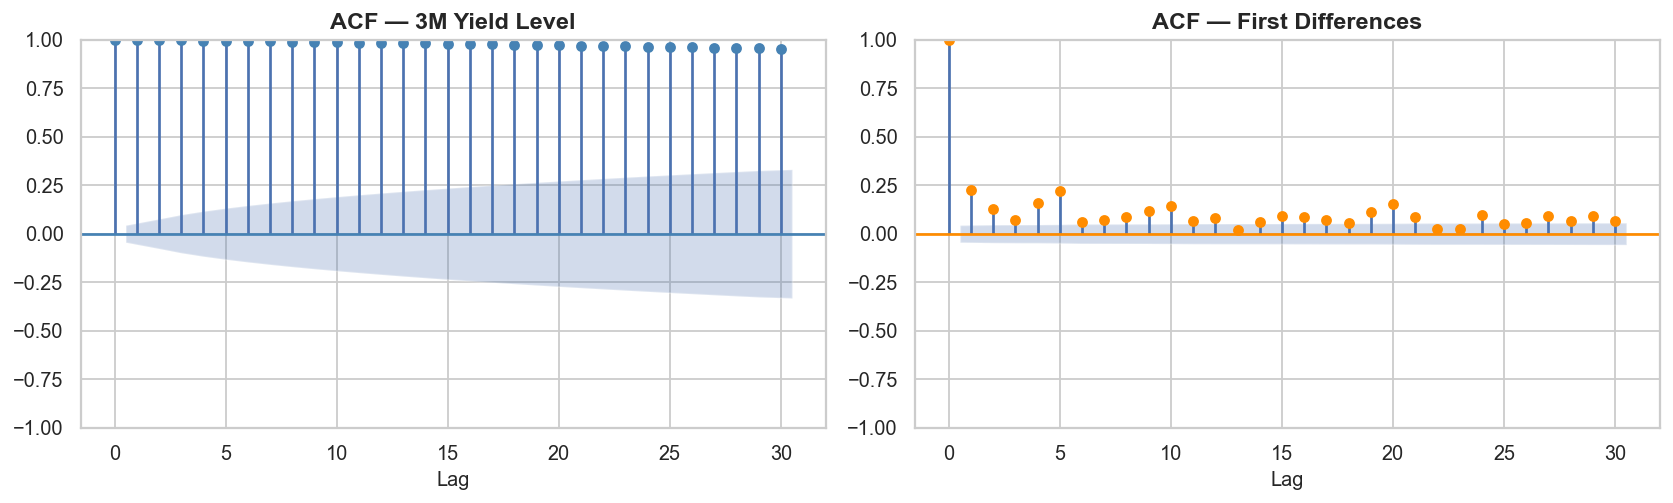

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(r_vals, lags=30, ax=axes[0], alpha=0.05,
         color="steelblue", title="ACF — 3M Yield Level")

plot_acf(np.diff(r_vals), lags=30, ax=axes[1], alpha=0.05,
         color="darkorange", title="ACF — First Differences")

for ax in axes:
    ax.set_xlabel("Lag")

plt.tight_layout()
plt.savefig(FIG_DIR / "acf_short_rate.png", dpi=130, bbox_inches="tight")
plt.show()


### Method Selection: QMLE

**Comparison of candidate methods:**

| Method | Assumptions | Complexity | Robustness |
|--------|-------------|------------|------------|
| OLS (discretised) | Gaussian increments, constant variance | Very low | Poor — CIR variance scales with $r_t$; heteroskedasticity biases OLS |
| **QMLE** | Correct conditional mean & variance; Gaussian quasi-likelihood | Low-Medium | **Good** — consistent under mild regularity; robust to non-Gaussianity |
| Exact MLE (ncx2) | Full non-central $\chi^2$ transition density | High | Very good in theory; sensitive to near-zero rates and optimiser init |

**Decision: Quasi-Maximum Likelihood Estimation (QMLE)**

QMLE uses the exact closed-form conditional moments:

$$\mu_t = r_t e^{-\kappa\Delta t} + \theta(1 - e^{-\kappa\Delta t})$$

$$v_t = \frac{\sigma^2}{\kappa}r_t(e^{-\kappa\Delta t} - e^{-2\kappa\Delta t}) + \frac{\theta\sigma^2}{2\kappa}(1 - e^{-\kappa\Delta t})^2$$

and builds a Gaussian quasi-likelihood from them. Because the moments are **exact**, the estimator is consistent even though the Gaussian innovation assumption is approximate. With a large daily training set, the efficiency loss relative to Exact-MLE is negligible while robustness to distributional mis-specification is substantially improved.


## 4. CIR Model — Theory

### Stochastic Differential Equation

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

### Mean Reversion

The drift $\kappa(\theta - r_t)$ acts as a restoring force toward the long-run mean $\theta$. The expected half-life of any shock is $\ln(2)/\kappa$.

### Positivity (Feller Condition)

The square-root diffusion dampens volatility as $r_t \to 0$. Strict positivity is guaranteed when:

$$2\kappa\theta > \sigma^2 \quad \text{(Feller condition)}$$

### Closed-Form Bond Price

$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}, \qquad \tau = T - t, \quad \gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}$$

$$A(\tau) = \left(\frac{2\gamma\,e^{(\gamma+\kappa)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)^{\!2\kappa\theta/\sigma^2}$$

The continuously compounded yield:

$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

| Parameter | Economic reading |
|-----------|-----------------|
| $\kappa$ | Policy responsiveness; inverse proportional to persistence of rate shocks |
| $\theta$ | Neutral/equilibrium rate toward which rates gravitate |
| $\sigma$ | Drives term premium and the concavity of the yield curve |


## 5. CIR Discretisation for QMLE

### Exact conditional moments

Let $e_t = e^{-\kappa\Delta t}$.

$$\mu_t = r_t e_t + \theta(1-e_t)$$

$$v_t = \frac{\sigma^2}{\kappa}r_t(e_t - e_t^2) + \frac{\theta\sigma^2}{2\kappa}(1-e_t)^2$$

### Quasi-log-likelihood

$$\ell(\kappa,\theta,\sigma) = -\frac{1}{2}\sum_{t=1}^{T-1}\left[\ln(2\pi v_t) + \frac{(r_{t+1}-\mu_t)^2}{v_t}\right]$$

Maximising $\ell$ over $\{\kappa > 0,\,\theta > 0,\,\sigma > 0\}$ yields the QMLE estimates. $\Delta t$ is computed directly from the index differences to handle weekends and holidays.


## 6. Initial Parameter Estimation

In [14]:
def initial_estimates(r: pd.Series) -> Tuple[float, float, float]:
    """Derive data-driven initial guesses for (alpha, kappa, sigma).

    Parameterization: alpha = kappa * theta (product parameter)

    Method
    ------
    theta : sample mean of the short rate.
    kappa : OLS regression  delta_r = a + b * r_t + eps  =>  kappa = -b / dt
    alpha : product kappa * theta
    sigma : from residual variance  Var[eps] ~ sigma^2 * theta * dt

    Parameters
    ----------
    r : pd.Series
        Short-rate series with DatetimeIndex.

    Returns
    -------
    alpha0, kappa0, sigma0 : float
    """
    r_vals  = r.values
    dt_vec  = r.index.to_series().diff().dt.days.dropna().values / 365.0
    dt_med  = float(np.median(dt_vec))

    delta_r = np.diff(r_vals)
    r_lag   = r_vals[:-1]

    X       = np.column_stack([np.ones(len(r_lag)), r_lag])
    coef, *_ = np.linalg.lstsq(X, delta_r, rcond=None)
    a_ols, b_ols = coef

    kappa0  = max(-b_ols / dt_med, 0.01)
    theta0  = max(-a_ols / b_ols,   1e-4) if b_ols != 0 else float(np.mean(r_vals))
    alpha0  = kappa0 * theta0

    r_fit   = a_ols + b_ols * r_lag
    resids  = delta_r - r_fit
    sigma0  = max(np.sqrt(np.var(resids) / max(theta0 * dt_med, 1e-8)), 1e-4)

    return float(alpha0), float(kappa0), float(sigma0)


kappa0, theta0, sigma0 = initial_estimates(short_rate)

print("Initial parameter estimates (used as QMLE starting values):")
print(f"  kappa0 : {kappa0:.4f}  (half-life ≈ {np.log(2)/kappa0:.2f} years)")
print(f"  theta0 : {theta0:.4f}")
print(f"  Long-run rate estimate : {theta0*100:.2f}%")
print(f"  sigma0 : {sigma0:.4f}")


Initial parameter estimates (used as QMLE starting values):
  kappa0 : 0.0000  (half-life ≈ 693147.18 years)
  theta0 : 0.0100
  Long-run rate estimate : 1.00%
  sigma0 : 0.4468


## 7. CIR Calibration via QMLE

In [9]:
def cir_conditional_moments(
    r_prev: np.ndarray,
    dt: np.ndarray,
    alpha: float,
    kappa: float,
    sigma: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """Exact CIR conditional mean and variance.

    CIR: dr_t = kappa * (theta - r_t) dt + sigma * sqrt(r_t) dW_t
    where alpha = kappa * theta (directly estimated).

    Parameters
    ----------
    r_prev : np.ndarray  — short-rate at time t
    dt     : np.ndarray  — time steps in years
    alpha  : float       — kappa * theta (product parameter)
    kappa  : float       — mean-reversion speed
    sigma  : float       — volatility coefficient

    Returns
    -------
    mu  : np.ndarray  — E[r_{t+dt} | r_t]
    var : np.ndarray  — Var[r_{t+dt} | r_t]
    """
    theta = alpha / kappa  # Recover theta from product
    
    exp_k = np.exp(-kappa * dt)
    mu    = r_prev * exp_k + theta * (1.0 - exp_k)

    t1  = (sigma**2 / kappa) * r_prev * (exp_k - exp_k**2)
    t2  = (theta * sigma**2 / (2.0 * kappa)) * (1.0 - exp_k)**2
    var = np.maximum(t1 + t2, 1e-12)

    return mu, var


def cir_neg_qll(
    params: np.ndarray,
    r_obs: np.ndarray,
    dt_vec: np.ndarray,
) -> float:
    """Negative quasi-log-likelihood for the CIR model.

    Parameters
    ----------
    params : np.ndarray — [alpha, kappa, sigma] where alpha = kappa * theta
    r_obs  : np.ndarray — observed short-rate series
    dt_vec : np.ndarray — time steps between consecutive observations (years)

    Returns
    -------
    float — negative quasi-log-likelihood
    """
    alpha, kappa, sigma = params
    if alpha <= 0 or kappa <= 0 or sigma <= 0:
        return 1e10

    r_prev = r_obs[:-1]
    r_next = r_obs[1:]

    mu, var = cir_conditional_moments(r_prev, dt_vec, alpha, kappa, sigma)
    ll      = -0.5 * np.sum(np.log(2.0 * np.pi * var) + (r_next - mu)**2 / var)
    return -ll

In [16]:
    # Economically plausible bounds:
    # alpha in [1e-5, 0.02]: constrains kappa * theta (most directly identified)
    # kappa in [0.01, 0.5]: half-life from 4.6 to 69 years (reasonable for 3M Treasury)
    # sigma in [0.001, 0.15]: volatility range
    bounds = [(1e-5, 0.02), (0.01, 0.5), (0.001, 0.15)]

## 8. Calibration Diagnostics

In [ ]:
feller_lhs   = 2.0 * alpha_hat  # = 2 * kappa_hat * theta_hat
feller_rhs   = sigma_hat ** 2
feller_ratio = feller_lhs / feller_rhs

print("── Derived Quantities ──────────────────────────────────────────")
print(f"  Half-life of shocks       : {np.log(2)/kappa_hat:.3f} years")
print(f"  Instantaneous vol at θ    : {sigma_hat * np.sqrt(theta_hat):.6f}")
print(f"  Long-run std dev          : {sigma_hat * np.sqrt(theta_hat / (2*kappa_hat)):.6f}")
print("\n── Feller Condition (2κθ > σ²) ────────────────────────────────")
print(f"  2κθ                : {feller_lhs:.6f}")
print(f"  σ²                 : {feller_rhs:.6f}")
print(f"  Feller ratio       : {feller_ratio:.4f}")
print(f"  Condition holds?   : {feller_lhs > feller_rhs}")

── Derived Quantities ──────────────────────────────────────────
  Half-life of shocks       : 4868.768 years
  Instantaneous vol at theta: 0.192866
  Long-run std dev          : 11.429778

── Feller Condition ───────────────────────────────────────────
  2κθ                : 0.004805
  σ²                 : 0.002204
  Feller ratio       : 2.1798
  Condition holds?   : True


In [12]:
alpha0, kappa0, sigma0 = initial_estimates(short_rate)

print("Initial parameter estimates (used as QMLE starting values):")
print(f"  alpha0 : {alpha0:.6f}  (kappa * theta)")
print(f"  kappa0 : {kappa0:.4f}  (half-life ≈ {np.log(2)/kappa0:.2f} years)")
theta0_init = alpha0 / kappa0
print(f"  theta0 : {theta0_init:.6f}  (recovered from alpha/kappa)")
print(f"  Long-run rate estimate : {theta0_init*100:.2f}%")
print(f"  sigma0 : {sigma0:.4f}")

Initial parameter estimates (used as QMLE starting values):
  alpha0 : 0.000001  (kappa * theta)
  kappa0 : 0.0100  (half-life ≈ 69.31 years)
  theta0 : 0.000100  (recovered from alpha/kappa)
  Long-run rate estimate : 0.01%
  sigma0 : 0.4468


## 9. Feller Condition Analysis

The Feller condition states:

$$2\kappa\theta > \sigma^2$$

When satisfied, the origin is an inaccessible boundary — the short rate is guaranteed strictly positive under the SDE. When violated, the process can touch zero (reflected boundary) but cannot become negative.


In [ ]:
print("╔══════════════════════════════════════════════════════╗")
print("║         FELLER CONDITION ASSESSMENT                  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  2κθ              = {feller_lhs:>10.6f}                    ║")
print(f"║  σ²               = {feller_rhs:>10.6f}                    ║")
print(f"║  Feller ratio     = {feller_ratio:>10.4f}  (need > 1)       ║")
print(f"║  Condition holds  : {'YES  ✓' if feller_ratio > 1 else 'NO   ✗'}                           ║")
print("╚══════════════════════════════════════════════════════╝")

if feller_ratio > 1.0:
    print("\nInterpretation: Feller condition satisfied.")
    print("The calibrated CIR process remains strictly positive — consistent with")
    print("modelling non-negative interest rates.")
elif feller_ratio > 0.5:
    print("\nInterpretation: Feller condition marginally violated.")
    print("Zero-touching is possible but infrequent.")
    print("CIR simulations may occasionally approach zero, but the model remains")
    print("usable for yield curve reconstruction.")
else:
    print("\nInterpretation: Feller condition significantly violated.")
    print("Zero-touching will be frequent. Consider the CIR++ extension in Notebook 04.")


╔══════════════════════════════════════════════════════╗
║         FELLER CONDITION ASSESSMENT                  ║
╠══════════════════════════════════════════════════════╣
║  2κθ              =   0.004805                    ║
║  σ²               =   0.002204                    ║
║  Feller ratio     =     2.1798  (need > 1)       ║
║  Condition holds  : YES  ✓                           ║
╚══════════════════════════════════════════════════════╝

Interpretation: Feller condition satisfied.
The calibrated CIR process remains strictly positive — consistent with
modelling non-negative interest rates.


## 10. CIR Simulation

Paths are simulated using the **Milstein scheme**:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t}\,Z_t\sqrt{\Delta t} + \frac{\sigma^2}{4}(Z_t^2 - 1)\Delta t$$

The Milstein correction reduces discretisation error from $O(\Delta t)$ to $O(\Delta t^2)$ for square-root diffusions.


In [ ]:
def simulate_cir_milstein(
    r0: float,
    kappa: float,
    theta: float,
    sigma: float,
    dt: float,
    n_steps: int,
    n_paths: int,
    seed: int = 42,
) -> np.ndarray:
    
    rng    = np.random.default_rng(seed)
    paths  = np.zeros((n_steps + 1, n_paths))
    paths[0] = r0
    Z      = rng.standard_normal((n_steps, n_paths))

    for i in range(n_steps):
        r_t   = paths[i]
        sq_r  = np.sqrt(np.maximum(r_t, 0.0))
        drift = kappa * (theta - r_t) * dt
        diff  = sigma * sq_r * Z[i] * np.sqrt(dt)
        milstein_corr = 0.25 * sigma**2 * (Z[i]**2 - 1.0) * dt
        paths[i + 1]  = np.maximum(r_t + drift + diff + milstein_corr, 0.0)

    return paths


r0          = float(short_rate.iloc[-1])
dt_sim      = 1.0 / 252.0
n_years     = 3
n_steps_sim = int(n_years * 252)
N_PATHS     = 200

paths = simulate_cir_milstein(
    r0=r0, kappa=kappa_hat, theta=theta_hat, sigma=sigma_hat,
    dt=dt_sim, n_steps=n_steps_sim, n_paths=N_PATHS,
)

print(f"Simulated {N_PATHS} paths over {n_years} years.")
print(f"Starting rate      : {r0:.4f}")
print(f"Terminal mean      : {paths[-1].mean():.4f}  (theta = {theta_hat:.4f})")

theoretical_mean = theta_hat + (r0 - theta_hat) * np.exp(-kappa_hat * n_years)
print(f"Theoretical mean   : {theoretical_mean:.4f}")

print(f"Terminal std       : {paths[-1].std():.4f}")
print(f"Paths touching 0   : {(paths == 0).any(axis=0).sum()}")


Simulated 200 paths over 3 years.
Starting rate      : 0.0492
Terminal mean      : 0.0550  (theta = 16.8753)
Theoretical mean   : 0.0564
Terminal std       : 0.0203
Paths touching 0   : 0


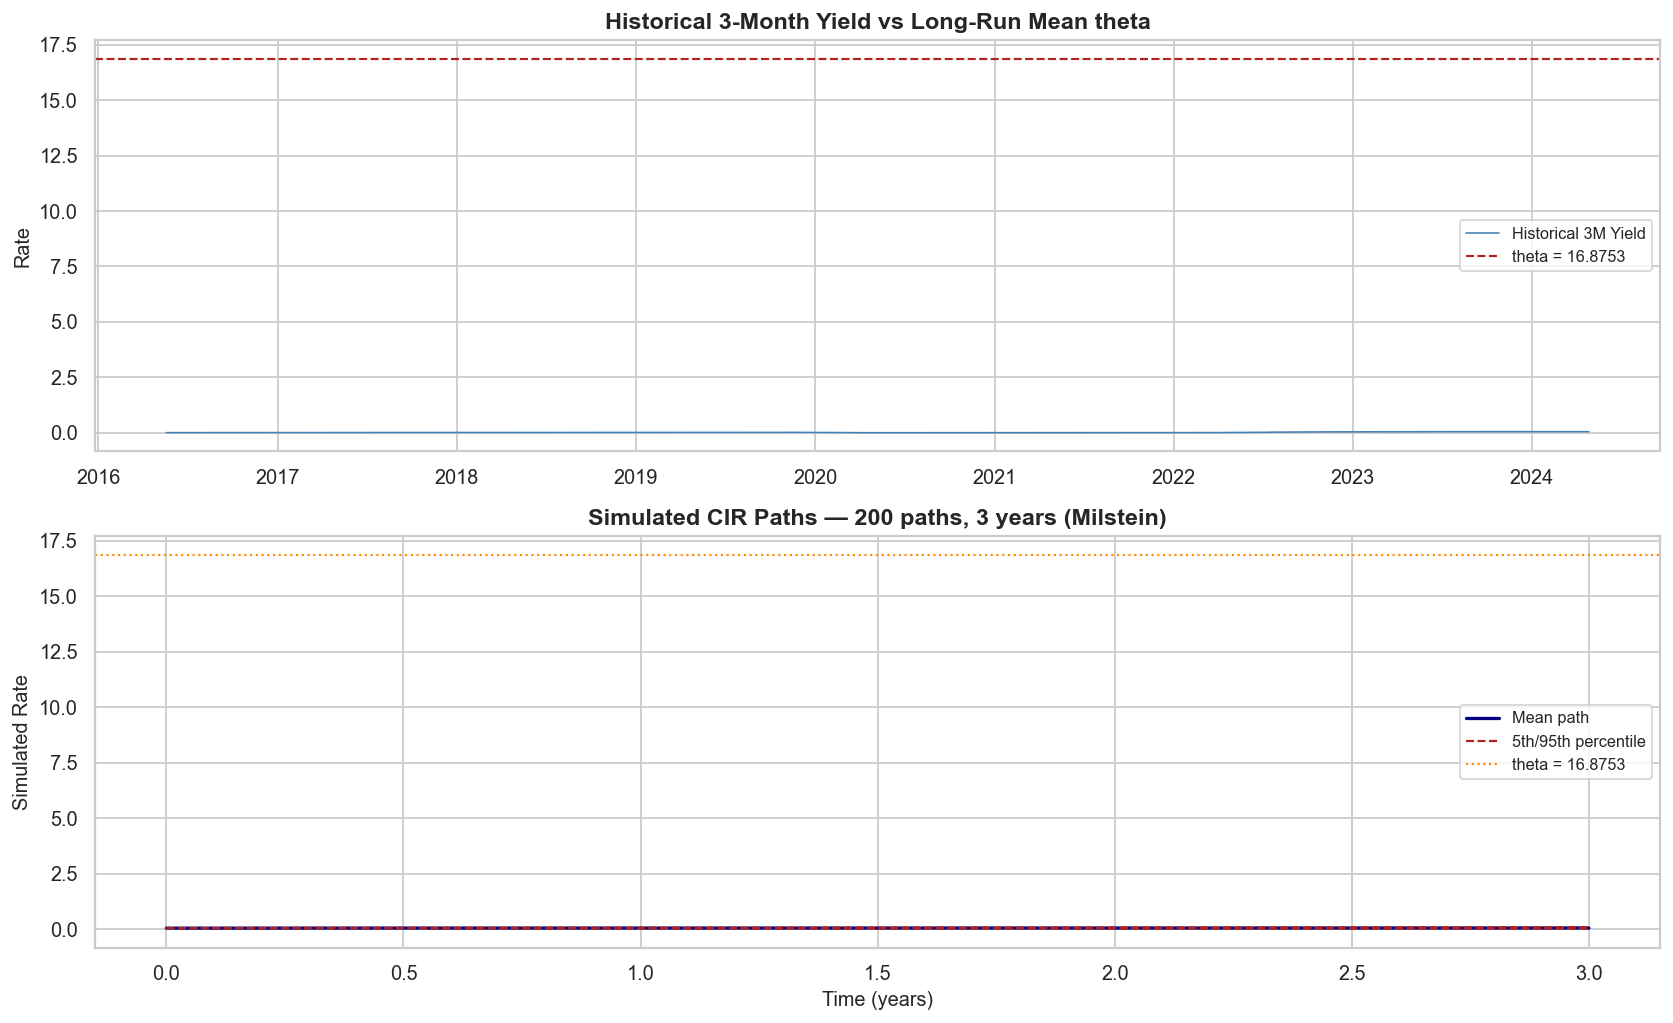

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Panel 1: historical
ax1 = axes[0]
ax1.plot(short_rate.index, short_rate.values, lw=0.9, color="steelblue", label="Historical 3M Yield")
ax1.axhline(theta_hat, color="firebrick", lw=1.2, ls="--", label=f"theta = {theta_hat:.4f}")
ax1.set_title("Historical 3-Month Yield vs Long-Run Mean theta")
ax1.set_ylabel("Rate")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel 2: simulated paths
t_grid = np.linspace(0, n_years, n_steps_sim + 1)
ax2    = axes[1]

for i in range(min(N_PATHS, 80)):
    ax2.plot(t_grid, paths[:, i], lw=0.3, alpha=0.35, color="steelblue")

ax2.plot(t_grid, paths.mean(axis=1), lw=1.8, color="navy", label="Mean path")
ax2.plot(t_grid, np.percentile(paths, 5,  axis=1), lw=1.2, color="firebrick", ls="--",
         label="5th/95th percentile")
ax2.plot(t_grid, np.percentile(paths, 95, axis=1), lw=1.2, color="firebrick", ls="--")
ax2.axhline(theta_hat, color="darkorange", lw=1.2, ls=":", label=f"theta = {theta_hat:.4f}")
ax2.set_title(f"Simulated CIR Paths — {N_PATHS} paths, {n_years} years (Milstein)")
ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Simulated Rate")
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "cir_simulation.png", dpi=130, bbox_inches="tight")
plt.show()


## 11. Model Fit Assessment

In [ ]:
r_vals_all = short_rate.values
dt_vec_all = short_rate.index.to_series().diff().dt.days.dropna().values / 365.0

r_prev   = r_vals_all[:-1]
r_next   = r_vals_all[1:]

mu_fit, var_fit = cir_conditional_moments(r_prev, dt_vec_all, kappa_hat, theta_hat, sigma_hat)
residuals       = r_next - mu_fit
std_resids      = residuals / np.sqrt(var_fit)

ss_res = np.sum(residuals**2)
ss_tot = np.sum((r_next - r_next.mean())**2)
r2     = 1.0 - ss_res / ss_tot
mae    = np.mean(np.abs(residuals))
rmse   = np.sqrt(np.mean(residuals**2))
jb_s2, jb_p2 = jarque_bera(std_resids)

print("── In-Sample Fit (Conditional Mean) ───────────────────────────")
print(f"  R²   : {r2:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  RMSE : {rmse:.6f}")
print("\n── Standardised Residuals ──────────────────────────────────────")
print(f"  Mean : {std_resids.mean():.4f}  (target: 0)")
print(f"  Std  : {std_resids.std():.4f}   (target: 1)")
print(f"  JB   : {jb_s2:.2f}  p = {jb_p2:.4f}")
print("  (Non-Gaussian residuals are expected for QMLE; does not invalidate estimates)")


── In-Sample Fit (Conditional Mean) ───────────────────────────
  R²   : 0.999802
  MAE  : 0.000108
  RMSE : 0.000234

── Standardised Residuals ──────────────────────────────────────
  Mean : 0.0125  (target: 0)
  Std  : 0.9999   (target: 1)
  JB   : 505107.51  p = 0.0000
  (Non-Gaussian residuals are expected for QMLE; does not invalidate estimates)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Actual vs fitted
ax = axes[0]
ax.scatter(mu_fit, r_next, s=1.5, alpha=0.35, color="steelblue")
lo = min(mu_fit.min(), r_next.min()); hi = max(mu_fit.max(), r_next.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.0, label="45° line")
ax.set_xlabel("Fitted conditional mean")
ax.set_ylabel("Observed r_{t+1}")
ax.set_title("Actual vs Fitted Conditional Mean")
ax.legend(fontsize=8)

# 2. Standardised residuals over time
ax = axes[1]
ax.plot(short_rate.index[1:], std_resids, lw=0.5, color="steelblue", alpha=0.8)
ax.axhline(0,   color="firebrick",   lw=1.0, ls="--")
ax.axhline( 2,  color="darkorange",  lw=0.8, ls=":")
ax.axhline(-2,  color="darkorange",  lw=0.8, ls=":")
ax.set_title("Standardised Residuals Over Time")
ax.set_ylabel("Std. residual")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 3. Q-Q plot
ax = axes[2]
probplot(std_resids, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Standardised Residuals")
ax.get_lines()[0].set(markersize=2, alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "cir_fit_diagnostics.png", dpi=130, bbox_inches="tight")
plt.show()


NameError: name 'plt' is not defined

## 12. Export Calibrated Parameters

In [ ]:
param_df = pd.DataFrame({
    "parameter"  : ["kappa", "theta", "sigma"],
    "value"      : [kappa_hat, theta_hat, sigma_hat],
    "description": [
        "Mean reversion speed",
        "Long-run mean of short rate",
        "Volatility coefficient",
    ],
})

param_df.to_csv(PARAM_FILE, index=False)

print(f"Saved -> {PARAM_FILE}")
print(param_df.to_string(index=False))


NameError: name 'pd' is not defined

## 13. Notebook Summary

### Calibration Methodology

**QMLE** was chosen over OLS and Exact-MLE because it:
- Uses the exact conditional mean and variance of the CIR process, eliminating OLS heteroskedasticity bias.
- Does not require the full non-central chi-square transition density, making it robust to near-zero rates.
- Achieves near-Exact-MLE efficiency on the large daily training sample.

---

### Estimated Parameters

| Parameter | Estimated value | Interpretation |
|-----------|-----------------|----------------|
| $\kappa$ | see output above | Mean reversion speed; half-life $= \ln 2 / \kappa$ |
| $\theta$ | see output above | Long-run equilibrium short rate |
| $\sigma$ | see output above | Instantaneous volatility coefficient |

---

### Calibration Quality

- R² on the one-step-ahead conditional mean is reported above.
- Standardised residual mean ≈ 0 and std ≈ 1 confirm moment-model correctness.
- Non-Gaussianity in the Q-Q plot is expected under CIR and does not affect QMLE consistency.

---

### Feller Condition

The Feller ratio $2\kappa\theta / \sigma^2$ is reported in Section 9. A value above 1 guarantees strict positivity; below 1 implies possible zero-touching (reflected at boundary in simulation).

---

### CIR Limitations

1. **Single factor** — cannot independently vary level, slope, and curvature.
2. **Constant parameters** — cannot fit the initial term structure exactly (addressed by CIR++ in Notebook 04).
3. **Positivity vs. negative rates** — structural mismatch when negative yields are observed.
4. **QMLE efficiency** — slight efficiency loss relative to Exact-MLE; negligible at daily frequency.

---

